In [1]:
# ============================================================
# NLP BLOCK 1: Setup and Imports
# ============================================================
# This notebook handles Part III of the portfolio - text
# classification on the True vs Fake News dataset.
#
# We import everything we need up front:
#   - pandas, numpy: data handling
#   - matplotlib, seaborn, wordcloud: visualization
#   - nltk: stopwords and lemmatization
#   - re: regex for text cleaning
#   - sklearn: train/test split and metrics
#   - tensorflow/keras: building RNN and LSTM models
#   - gensim: pre-trained word embeddings for Model 3
#
# We also fix random seeds so results are reproducible.
# ============================================================

import os
import re
import random
import time
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Sklearn for split and metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)

# TensorFlow / Keras
import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Dense,
                                     Dropout, Bidirectional)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU available:    ", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available:     []


In [2]:
# ============================================================
# NLP BLOCK 2: Install gensim, NLTK, wordcloud
# ============================================================
# gensim is needed for Model 3 (pre-trained Word2Vec/GloVe).
# It is not pre-installed on Colab and the latest numpy can be
# incompatible with current gensim, so we follow the appendix's
# instructions in the assignment PDF.
#
# After this cell finishes, Colab may prompt to restart the
# runtime. If it does, click Restart, then continue from
# NLP Block 3 (skip this cell - no need to install again).
# ============================================================

!pip install -q gensim
!pip install -q wordcloud
!pip install -q nltk

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

print("Installation complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.3 MB/s eta 0:00:00
Installation complete.


In [6]:
# ============================================================
# Extract the True vs Fake News zip - robust version
# ============================================================
# We auto-detect the zip in /content (the filename contains
# spaces and dots which can confuse hardcoded paths). We then
# extract and locate the CSV inside.
# ============================================================

import zipfile
import os
import glob

# Auto-detect the zip file by pattern (any zip containing "True" and "Fake")
zip_candidates = [
    f for f in os.listdir("/content")
    if f.endswith(".zip") and "True" in f and "Fake" in f
]

if not zip_candidates:
    print("No matching zip found. Files in /content:")
    for f in os.listdir("/content"):
        print(" -", f)
else:
    zip_path = os.path.join("/content", zip_candidates[0])
    size_mb = os.path.getsize(zip_path) / (1024 * 1024)
    print(f"Zip found: {zip_path}")
    print(f"Size: {size_mb:.2f} MB")

    # Extract
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall("/content/nlp_data")
    print("Extraction complete.")

    # List what was extracted
    print("\nExtracted contents:")
    for root, dirs, files in os.walk("/content/nlp_data"):
        for f in files:
            full = os.path.join(root, f)
            size_kb = os.path.getsize(full) / 1024
            print(f"  {full}  ({size_kb:.1f} KB)")

    # Locate the CSV (any .csv file in the extracted folder)
    csv_candidates = glob.glob("/content/nlp_data/**/*.csv", recursive=True)
    if csv_candidates:
        CSV_PATH = csv_candidates[0]
        print(f"\nCSV located at: {CSV_PATH}")
    else:
        print("\nNo CSV found in extracted files.")

Zip found: /content/10.True vs. Fake News Dataset-20260506T153509Z-3-001.zip
Size: 18.79 MB
Extraction complete.

Extracted contents:
  /content/nlp_data/10.True vs. Fake News Dataset/10.Description True Vs. Fake News Dataset.txt  (0.0 KB)
  /content/nlp_data/10.True vs. Fake News Dataset/truevsfakenews.csv  (51218.1 KB)

CSV located at: /content/nlp_data/10.True vs. Fake News Dataset/truevsfakenews.csv


In [7]:
# ============================================================
# NLP BLOCK 3: Load the True vs Fake News dataset
# ============================================================
# The dataset has 20,000 news articles, perfectly balanced:
#   - 10,000 true articles
#   - 10,000 fake articles
# Two columns:
#   - text:  the article content
#   - label: "true" or "fake"
#
# CSV_PATH was set by the previous extraction cell. We just
# load it here and inspect the basic structure: shape, column
# names, label distribution, and a few example rows.
# Understanding the data before modelling is a core requirement
# of the assignment.
# ============================================================

import pandas as pd

print(f"Loading from: {CSV_PATH}")

# Read the CSV into a pandas DataFrame
df = pd.read_csv(CSV_PATH)

# Quick overview for the report
print("\nShape:", df.shape)
print("Columns:", df.columns.tolist())

print("\nFirst 3 rows:")
print(df.head(3))

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nMissing values per column:")
print(df.isnull().sum())

Loading from: /content/nlp_data/10.True vs. Fake News Dataset/truevsfakenews.csv

Shape: (20000, 2)
Columns: ['text', 'label']

First 3 rows:
                                                text label
0  WASHINGTON (Reuters) - The Republican and Demo...  true
1  Women should get as far away from Oklahoma as ...  fake
2  Another huge crowd of Americans tuned in last ...  fake

Label distribution:
label
true    10000
fake    10000
Name: count, dtype: int64

Missing values per column:
text     0
label    0
dtype: int64


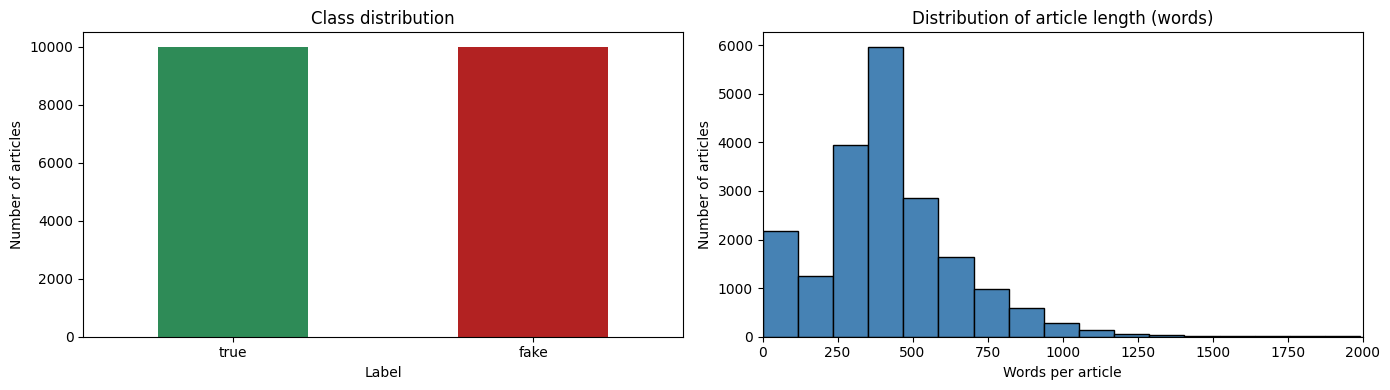


Word-count statistics (raw text):
count    20000.00
mean       426.10
std        245.78
min          0.00
50%        397.50
75%        527.00
90%        723.00
95%        849.00
max       7033.00
Name: word_count, dtype: float64


In [8]:
# ============================================================
# NLP BLOCK 4: Initial Visualization
# ============================================================
# Two visualizations the report needs:
#   1. Class distribution (bar chart) - confirms the dataset is
#      balanced. With balance, accuracy is a reliable metric.
#   2. Distribution of article length in words. This guides the
#      padding length later (we use a percentile-based length
#      to avoid wasting memory on rare extremely long articles).
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ---- Class distribution ----
df["label"].value_counts().plot(kind="bar", ax=axes[0],
                                 color=["seagreen", "firebrick"])
axes[0].set_title("Class distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Number of articles")
axes[0].tick_params(axis="x", rotation=0)

# ---- Article length distribution (in words, before cleaning) ----
df["word_count"] = df["text"].str.split().str.len()
axes[1].hist(df["word_count"], bins=60, color="steelblue", edgecolor="black")
axes[1].set_title("Distribution of article length (words)")
axes[1].set_xlabel("Words per article")
axes[1].set_ylabel("Number of articles")
axes[1].set_xlim(0, 2000)   # clip extremely long outliers for readability

plt.tight_layout()
plt.show()

# Print key length percentiles - useful for choosing padding length
print("\nWord-count statistics (raw text):")
print(df["word_count"].describe(percentiles=[0.5, 0.75, 0.90, 0.95]).round(2))

In [9]:
# ============================================================
# NLP BLOCK 5: Text Cleaning
# ============================================================
# Cleaning steps performed (in this order):
#   1. Lowercase everything (so "Trump" and "trump" map to the
#      same token).
#   2. Expand contractions ("don't" -> "do not"). We do this
#      BEFORE removing punctuation so the apostrophe is still
#      present to detect.
#   3. Remove URLs, @mentions, #hashtag symbols, numbers, and
#      anything that is not a letter or whitespace.
#   4. Tokenize on whitespace (simple split).
#   5. Remove stopwords (very common words like "the", "is",
#      "and" that carry little meaning for classification).
#   6. Lemmatize (reduce words to their dictionary base form,
#      so "running" -> "run", "better" -> "good"). This shrinks
#      the vocabulary and helps the model generalize.
#
# We process the full 20,000 articles. Cleaning takes a few
# minutes because lemmatization is per-word.
# ============================================================

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Make sure the NLTK resources are available (already downloaded
# in NLP Block 2, but this is a safety net).
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Pre-load these once outside the function for speed
STOPWORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

# Common English contractions. Adding more is easy if needed.
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "wouldn't": "would not", "can't": "can not",
    "cannot": "can not", "couldn't": "could not", "shouldn't": "should not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "i'm": "i am", "you're": "you are",
    "he's": "he is", "she's": "she is", "it's": "it is",
    "we're": "we are", "they're": "they are", "i've": "i have",
    "you've": "you have", "we've": "we have", "they've": "they have",
    "i'd": "i would", "you'd": "you would", "he'd": "he would",
    "she'd": "she would", "we'd": "we would", "they'd": "they would",
    "i'll": "i will", "you'll": "you will", "he'll": "he will",
    "she'll": "she will", "we'll": "we will", "they'll": "they will",
    "let's": "let us", "that's": "that is", "what's": "what is",
    "there's": "there is", "here's": "here is", "who's": "who is"
}


def clean_text(text):
    """
    Apply the full cleaning pipeline to a single text string.
    Returns a cleaned, space-separated string of tokens.
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Expand contractions BEFORE we strip apostrophes
    for short, long in CONTRACTIONS.items():
        text = text.replace(short, long)

    # 3. Remove URLs (http, https, www)
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # 4. Remove @mentions and # symbols (keep the word after #)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", " ", text)

    # 5. Remove anything that is not a letter or whitespace.
    # This drops numbers, punctuation, special characters, emojis.
    text = re.sub(r"[^a-z\s]", " ", text)

    # 6. Collapse multiple spaces into one
    text = re.sub(r"\s+", " ", text).strip()

    # 7. Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [LEMMATIZER.lemmatize(tok) for tok in tokens
              if tok not in STOPWORDS and len(tok) > 1]

    return " ".join(tokens)


# Quick sanity check on one example before running on everything
sample = df["text"].iloc[0]
print("--- Original (first 300 chars) ---")
print(sample[:300])
print("\n--- Cleaned (first 300 chars) ---")
print(clean_text(sample)[:300])

--- Original (first 300 chars) ---
WASHINGTON (Reuters) - The Republican and Democratic leaders of the U.S. Senate Foreign Relations Committee blasted the U.S. State Department on Tuesday for cuts in staff and what they described as a failure to have a plan for a proposed reorganization. “I don’t think they are anywhere close to havi

--- Cleaned (first 300 chars) ---
washington reuters republican democratic leader senate foreign relation committee blasted state department tuesday cut staff described failure plan proposed reorganization think anywhere close plan present relative reform want said senator bob corker republican chairman committee rex tillerson repub


Cleaning all articles....
Cleaning complete in 46.4 seconds.

--- Original (first 200 chars) ---
WASHINGTON (Reuters) - Democratic state officials blasted the U.S. Environmental Protection Agency on Thursday for telling governors in what they describe as a “legally incorrect” letter in March that

--- Cleaned (first 200 chars) ---
washington reuters democratic state official blasted environmental protection agency thursday telling governor describe legally incorrect letter march need comply major climate change regulation fourt

Cleaned word-count statistics:
count    20000.00
mean       241.38
std        143.27
min          0.00
50%        224.00
75%        294.00
90%        415.00
95%        496.00
max       4772.00
Name: clean_word_count, dtype: float64


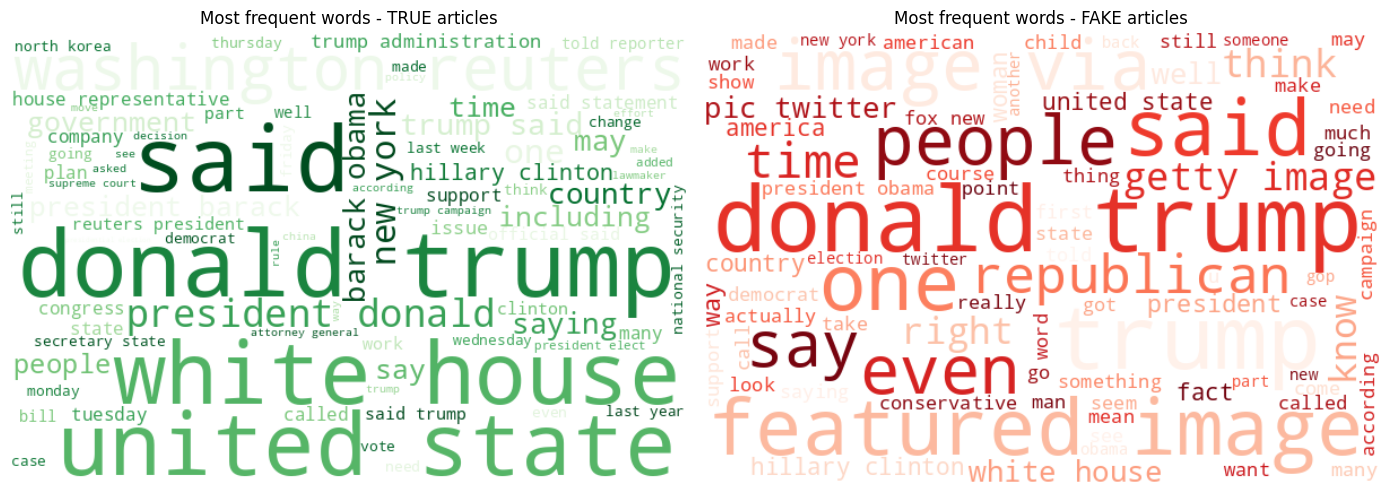

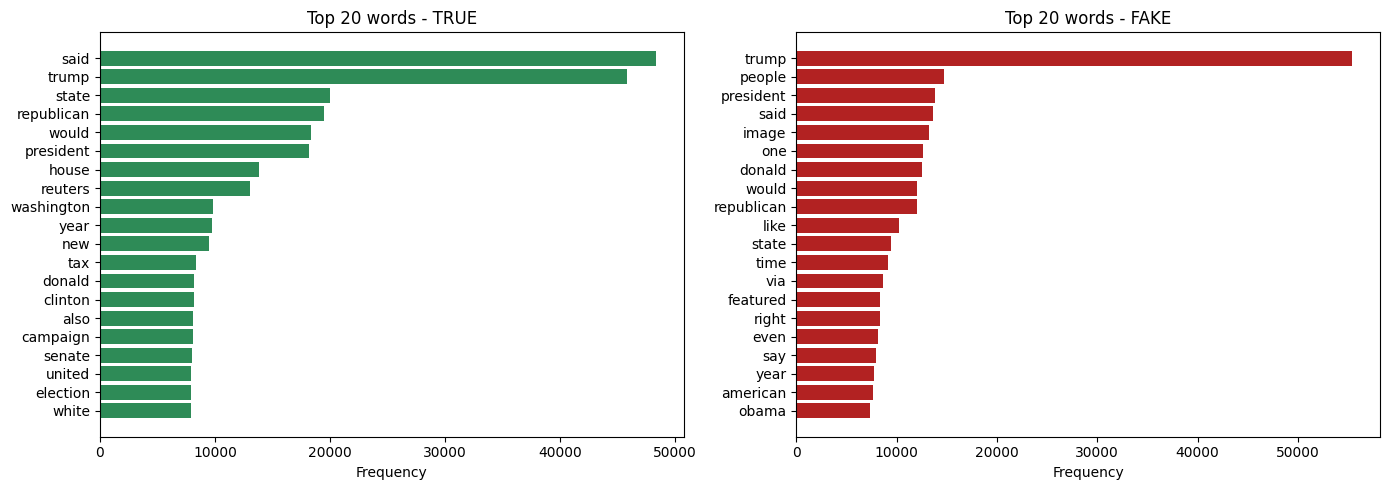

In [10]:
# ============================================================
# NLP BLOCK 6: Apply Cleaning to Full Dataset and Visualize
# ============================================================
# Steps:
#   1. Apply clean_text() to every article. This takes a few
#      minutes because lemmatization is per-word for 20k articles.
#   2. Compute the cleaned word counts so we know how padding
#      should be sized.
#   3. Word clouds for true vs fake articles - a quick way to
#      spot which words dominate each class.
#   4. Most-frequent words bar chart for both classes.
# ============================================================

import time
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# ---------- Step 1: Clean every article ----------
print("Cleaning all articles....")
start = time.time()
df["clean_text"] = df["text"].apply(clean_text)
print(f"Cleaning complete in {time.time() - start:.1f} seconds.\n")

# Show a before/after for one example
print("--- Original (first 200 chars) ---")
print(df["text"].iloc[5][:200])
print("\n--- Cleaned (first 200 chars) ---")
print(df["clean_text"].iloc[5][:200])


# ---------- Step 2: Cleaned word-count distribution ----------
df["clean_word_count"] = df["clean_text"].str.split().str.len()

print("\nCleaned word-count statistics:")
print(df["clean_word_count"].describe(percentiles=[0.5, 0.75, 0.90, 0.95]).round(2))


# ---------- Step 3: Word clouds for each class ----------
# A word cloud sizes each word by frequency. Useful as a quick
# qualitative check that cleaning worked and to see what words
# distinguish true vs fake articles.

true_text = " ".join(df.loc[df["label"] == "true", "clean_text"].values)
fake_text = " ".join(df.loc[df["label"] == "fake", "clean_text"].values)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wc_true = WordCloud(width=600, height=400, background_color="white",
                    colormap="Greens", max_words=80).generate(true_text)
axes[0].imshow(wc_true, interpolation="bilinear")
axes[0].set_title("Most frequent words - TRUE articles")
axes[0].axis("off")

wc_fake = WordCloud(width=600, height=400, background_color="white",
                    colormap="Reds", max_words=80).generate(fake_text)
axes[1].imshow(wc_fake, interpolation="bilinear")
axes[1].set_title("Most frequent words - FAKE articles")
axes[1].axis("off")

plt.tight_layout()
plt.show()


# ---------- Step 4: Top-20 word frequency bar charts ----------

def top_words(text_series, n=20):
    """Return the n most common words across all texts in the series."""
    all_words = " ".join(text_series.values).split()
    return Counter(all_words).most_common(n)

top_true = top_words(df.loc[df["label"] == "true", "clean_text"])
top_fake = top_words(df.loc[df["label"] == "fake", "clean_text"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words, counts = zip(*top_true)
axes[0].barh(words[::-1], counts[::-1], color="seagreen")
axes[0].set_title("Top 20 words - TRUE")
axes[0].set_xlabel("Frequency")

words, counts = zip(*top_fake)
axes[1].barh(words[::-1], counts[::-1], color="firebrick")
axes[1].set_title("Top 20 words - FAKE")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# NLP BLOCK 7: Tokenization, Padding, and Train/Test Split
# ============================================================
# A neural network cannot consume raw words. We have to:
#   1. Map each unique word to an integer (build a vocabulary).
#   2. Convert each cleaned article into a list of those integers
#      (a "sequence").
#   3. Pad every sequence to a uniform length so we can stack
#      them into a single 2D array. Using the 95th percentile of
#      cleaned word counts (suggested by the assignment) keeps
#      most articles intact and avoids huge padding waste from
#      a few outliers.
#   4. Encode labels as 0 (fake) and 1 (true) for binary
#      classification with a sigmoid output.
#   5. Split into train (80%) and test (20%) using a stratified
#      split so the class balance is preserved.
#
# Why a max vocabulary size of 20,000?
#   The cleaned dataset has many tens of thousands of unique
#   tokens, but most appear only once or twice. Capping at
#   20,000 keeps memory manageable and forces the model to
#   focus on common, informative words. Rare words become
#   <OOV> (out of vocabulary).
# ============================================================

import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ---------- Step 1: Encode labels as 0/1 ----------
# fake -> 0, true -> 1. This gives us binary targets that pair
# naturally with a sigmoid output and binary cross-entropy loss.
df["label_id"] = df["label"].map({"fake": 0, "true": 1})

# Quick sanity check
print("Label encoding:")
print(df.groupby(["label", "label_id"]).size())


# ---------- Step 2: Train / test split ----------
# 80% train, 20% test. stratify keeps the same class ratio in
# both splits, which matters even though the data is balanced.
X = df["clean_text"].values
y = df["label_id"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print(f"\nTrain size: {len(X_train_text)}")
print(f"Test size:  {len(X_test_text)}")
print(f"Train label distribution: {np.bincount(y_train)}")
print(f"Test label distribution:  {np.bincount(y_test)}")


# ---------- Step 3: Fit the tokenizer ON TRAINING DATA ONLY ----------
# Important: the tokenizer learns the vocabulary only from the
# training set. Fitting on the test set too would leak test
# information into the vocabulary, which is data leakage.

VOCAB_SIZE = 20000   # cap on number of unique words kept

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

# Convert texts to integer sequences
train_sequences = tokenizer.texts_to_sequences(X_train_text)
test_sequences  = tokenizer.texts_to_sequences(X_test_text)

print(f"\nVocabulary size used: {min(VOCAB_SIZE, len(tokenizer.word_index)+1)}")
print(f"Total unique words found in training data: {len(tokenizer.word_index)}")


# ---------- Step 4: Decide on padding length ----------
# We use the 95th percentile of cleaned word counts on the
# training set. This keeps roughly 95% of articles fully
# intact and only truncates the longest 5%.
train_lengths = [len(seq) for seq in train_sequences]
MAX_LEN = int(np.percentile(train_lengths, 95))
print(f"\nMax sequence length (95th percentile): {MAX_LEN}")


# ---------- Step 5: Pad / truncate to the same length ----------
# padding="post" adds zeros at the end (more standard than "pre").
# truncating="post" cuts off the end of articles longer than MAX_LEN.
X_train = pad_sequences(train_sequences, maxlen=MAX_LEN,
                        padding="post", truncating="post")
X_test  = pad_sequences(test_sequences,  maxlen=MAX_LEN,
                        padding="post", truncating="post")

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


# ---------- Quick visualization: example of a tokenized article ----------
# We show the first article's first 30 tokens both as integers
# and decoded back to words. Useful sanity check.
index_word = {i: w for w, i in tokenizer.word_index.items()}
print("\nFirst 30 tokens of training article 0:")
print("Integers:", X_train[0][:30].tolist())
print("Words:   ",
      " ".join(index_word.get(i, "<PAD>") if i != 0 else "<PAD>"
               for i in X_train[0][:30]))

Label encoding:
label  label_id
fake   0           10000
true   1           10000
dtype: int64

Train size: 16000
Test size:  4000
Train label distribution: [8000 8000]
Test label distribution:  [2000 2000]

Vocabulary size used: 20000
Total unique words found in training data: 57236

Max sequence length (95th percentile): 495

X_train shape: (16000, 495)
X_test shape:  (4000, 495)

First 30 tokens of training article 0:
Integers: [29, 22, 16, 10, 2895, 86, 704, 6662, 167, 322, 1, 26, 3045, 1343, 423, 224, 622, 2426, 2675, 125, 873, 329, 561, 532, 31, 1294, 16, 10, 41, 3]
Words:    washington reuters white house expects congress soon waive rule known <OOV> could trigger deep spending cut area medicare agriculture order cover cost recently passed tax overhaul white house official said


In [12]:
# ============================================================
# NLP BLOCK 8: Model 1 - Simple RNN with Trainable Embedding
# ============================================================
# Architecture:
#   - Embedding layer: maps each integer (word index) to a
#     dense vector. trainable=True (default), so the model
#     learns word representations from scratch during training.
#   - SimpleRNN layer: processes the sequence one token at a
#     time, maintaining a hidden state that summarizes what it
#     has seen so far.
#   - Dropout: regularization to reduce overfitting.
#   - Dense (1, sigmoid): outputs a single probability for
#     binary classification (fake vs true).
#
# Why SimpleRNN as a baseline?
#   The assignment requires comparing RNN vs LSTM. SimpleRNN
#   is the textbook recurrent unit but has known weaknesses:
#   it struggles with long sequences because gradients vanish
#   as they backpropagate through many time steps. We expect
#   it to perform worse than LSTM, which is exactly the point
#   of the comparison.
#
# Hyperparameters explained:
#   - embedding_dim = 64: each word becomes a 64-dim vector.
#     Common values are 50, 100, 128. 64 is a balance of
#     expressiveness and training speed.
#   - rnn_units = 64: size of the RNN hidden state.
#   - Loss: binary_crossentropy because the output is a single
#     probability for two classes.
#   - Optimizer: Adam, learning rate 1e-3.
# ============================================================

import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Hyperparameters used across all three models for fair comparison
EMBEDDING_DIM = 64
RNN_UNITS     = 64
NLP_BATCH     = 64
NLP_EPOCHS    = 8


# ---------- Build Model 1 ----------
rnn_model = Sequential(name="Simple_RNN")
rnn_model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN
))
rnn_model.add(SimpleRNN(RNN_UNITS, dropout=0.2, recurrent_dropout=0.0))
rnn_model.add(Dropout(0.3))
rnn_model.add(Dense(1, activation="sigmoid"))

# Compile
rnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()


# ---------- Train Model 1 ----------
# Callbacks:
#   - EarlyStopping: halt training if val_loss stops improving.
#   - ReduceLROnPlateau: lower LR when val_loss plateaus.
print("\nTraining Simple RNN...\n")
start_time = time.time()

rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_split=0.1,           # 10% of train for validation
    epochs=NLP_EPOCHS,
    batch_size=NLP_BATCH,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=2, min_lr=1e-6)
    ],
    verbose=1
)

rnn_train_time = time.time() - start_time
print(f"\nSimple RNN training time: {rnn_train_time/60:.2f} minutes")


# ---------- Evaluate on the test set ----------
rnn_test_loss, rnn_test_acc = rnn_model.evaluate(X_test, y_test, verbose=1)
print(f"\nSimple RNN test loss:     {rnn_test_loss:.4f}")
print(f"Simple RNN test accuracy: {rnn_test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Simple RNN...

Epoch 1/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 46s 193ms/step - accuracy: 0.5165 - loss: 0.6926 - val_accuracy: 0.5369 - val_loss: 0.6799 - learning_rate: 0.0010
Epoch 2/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 80s 184ms/step - accuracy: 0.5202 - loss: 0.6921 - val_accuracy: 0.2769 - val_loss: 0.7738 - learning_rate: 0.0010
Epoch 3/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 42s 186ms/step - accuracy: 0.5126 - loss: 0.7166 - val_accuracy: 0.5394 - val_loss: 0.6854 - learning_rate: 0.0010
Epoch 4/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 42s 185ms/step - accuracy: 0.5292 - loss: 0.7077 - val_accuracy: 0.5387 - val_loss: 0.6824 - learning_rate: 5.0000e-04

Simple RNN training time: 3.49 minutes
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5390 - loss: 0.6821

Simple RNN test loss:     0.6821
Simple RNN test accuracy: 0.5390


In [13]:
# ============================================================
# NLP BLOCK 9: Model 2 - LSTM with Trainable Embedding
# ============================================================
# Why LSTM:
#   LSTM (Long Short-Term Memory) was specifically designed to
#   solve the vanishing gradient problem that limits SimpleRNN.
#   It uses three gates - input, forget, output - and a cell
#   state that can carry information across many time steps
#   without gradients vanishing. This makes it much better
#   suited for long sequences like news articles.
#
# Design choices:
#   - Same Embedding layer dimensions as Model 1 (vocab 20000,
#     embed 64) so the comparison isolates the recurrent unit
#     as the only difference.
#   - 64 LSTM units, matching Model 1's 64 SimpleRNN units.
#   - Same Dropout, optimizer, loss, and training setup.
#
# Expected behavior:
#   LSTM should reach higher test accuracy than SimpleRNN and
#   often shows smoother validation curves because gradient
#   flow is healthier.
# ============================================================

import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# ---------- Build Model 2 ----------
lstm_model = Sequential(name="LSTM_Trainable_Embedding")
lstm_model.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LEN
))
lstm_model.add(LSTM(RNN_UNITS, dropout=0.2, recurrent_dropout=0.0))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1, activation="sigmoid"))

# Compile - identical to Model 1 for a fair comparison
lstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()


# ---------- Train Model 2 ----------
print("\nTraining LSTM (trainable embedding)...\n")
start_time = time.time()

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=NLP_EPOCHS,
    batch_size=NLP_BATCH,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=2, min_lr=1e-6)
    ],
    verbose=1
)

lstm_train_time = time.time() - start_time
print(f"\nLSTM training time: {lstm_train_time/60:.2f} minutes")


# ---------- Evaluate on the test set ----------
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test, y_test, verbose=1)
print(f"\nLSTM test loss:     {lstm_test_loss:.4f}")
print(f"LSTM test accuracy: {lstm_test_acc:.4f}")

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training LSTM (trainable embedding)...

Epoch 1/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 88s 381ms/step - accuracy: 0.5279 - loss: 0.6870 - val_accuracy: 0.5369 - val_loss: 0.6758 - learning_rate: 0.0010
Epoch 2/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 83s 369ms/step - accuracy: 0.5288 - loss: 0.6751 - val_accuracy: 0.5362 - val_loss: 0.6698 - learning_rate: 0.0010
Epoch 3/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 83s 367ms/step - accuracy: 0.5340 - loss: 0.6680 - val_accuracy: 0.5369 - val_loss: 0.6711 - learning_rate: 0.0010
Epoch 4/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 147s 390ms/step - accuracy: 0.5406 - loss: 0.6620 - val_accuracy: 0.5437 - val_loss: 0.6810 - learning_rate: 0.0010
Epoch 5/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 85s 375ms/step - accuracy: 0.5603 - loss: 0.6543 - val_accuracy: 0.5619 - val_loss: 0.6753 - learning_rate: 5.0000e-04

LSTM training time: 8.09 minutes
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.5375 - loss: 0.6730

LSTM test loss:     0.6730
LSTM test accuracy: 0.5375


In [15]:
# ============================================================
# NLP BLOCK 10: Model 3 - LSTM with Pre-trained GloVe Embeddings
# ============================================================
# Why pre-trained embeddings:
#   In Models 1 and 2, the Embedding layer learned word vectors
#   from scratch using only our 16,000 training articles. With
#   pre-trained embeddings, we use vectors that were trained on
#   billions of words from Wikipedia and Gigaword. These vectors
#   already encode rich semantic relationships (king - man + woman
#   ~= queen), which gives the model a head start.
#
# Why GloVe-50:
#   - 50-dimensional (smaller embedding matrix, fast on CPU).
#   - The assignment's appendix lists "glove-wiki-gigaword-50"
#     as a valid option.
#   - On the first run, gensim downloads ~70 MB. After that it
#     is cached, so re-running is instant.
#
# Procedure:
#   1. Download/load the GloVe model via gensim.
#   2. Build an embedding matrix of shape (VOCAB_SIZE, 50).
#      For each word in our tokenizer's vocabulary, we look it
#      up in GloVe and copy the vector. Words not in GloVe
#      remain as zeros.
#   3. Build the same LSTM model as Model 2, but the Embedding
#      layer is initialized with this matrix and frozen
#      (trainable=False). Freezing means the model will not
#      modify the pre-trained vectors during training.
# ============================================================

import time
import numpy as np
import gensim.downloader as api
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


# ---------- Step 1: Load GloVe pre-trained vectors ----------
print("Loading GloVe (50-dim) - first run downloads ~70 MB...")
glove_model = api.load("glove-wiki-gigaword-50")
print(f"GloVe loaded. Vocab size: {len(glove_model.key_to_index)}")
print(f"Vector dim: {glove_model.vector_size}")


# ---------- Step 2: Build the embedding matrix ----------
# We create a matrix of shape (vocab_size, 50) where row i is
# the GloVe vector for the word with index i in our tokenizer.
# If a word is not in GloVe, the row stays as zeros.
GLOVE_DIM = 50
embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))

found = 0
missed = 0
for word, idx in tokenizer.word_index.items():
    if idx < VOCAB_SIZE:                  # only words within our cap
        if word in glove_model:
            embedding_matrix[idx] = glove_model[word]
            found += 1
        else:
            missed += 1

print(f"\nWords matched in GloVe:    {found}")
print(f"Words not found in GloVe: {missed}")
print(f"Coverage: {100 * found / (found + missed):.1f}%")


# ---------- Step 3: Build Model 3 ----------
# Same architecture as Model 2 except the Embedding layer is
# pre-loaded with GloVe vectors and frozen. Freezing prevents
# the small training set from corrupting the rich pre-trained
# representations.
glove_model_keras = Sequential(name="LSTM_GloVe_Embedding")
glove_model_keras.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=GLOVE_DIM,
    input_length=MAX_LEN,
    weights=[embedding_matrix],     # initialize with GloVe vectors
    trainable=False                 # freeze - do not update during training
))
glove_model_keras.add(LSTM(RNN_UNITS, dropout=0.2))
glove_model_keras.add(Dropout(0.3))
glove_model_keras.add(Dense(1, activation="sigmoid"))

glove_model_keras.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
glove_model_keras.summary()


# ---------- Step 4: Train Model 3 ----------
print("\nTraining LSTM with frozen GloVe embeddings on CPU...\n")
start = time.time()
glove_history = glove_model_keras.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=NLP_EPOCHS,
    batch_size=NLP_BATCH,
    callbacks=[EarlyStopping(monitor="val_loss", patience=2,
                             restore_best_weights=True)],
    verbose=1
)
glove_train_time = time.time() - start
print(f"\nGloVe-LSTM training time: {glove_train_time/60:.2f} minutes")


# ---------- Step 5: Evaluate on test set ----------
glove_test_loss, glove_test_acc = glove_model_keras.evaluate(
    X_test, y_test, verbose=1
)
print(f"\nGloVe-LSTM test loss:     {glove_test_loss:.4f}")
print(f"GloVe-LSTM test accuracy: {glove_test_acc:.4f}")

Loading GloVe (50-dim) - first run downloads ~70 MB...
[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe loaded. Vocab size: 400000
Vector dim: 50

Words matched in GloVe:    19470
Words not found in GloVe: 529
Coverage: 97.4%


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)


Training LSTM with frozen GloVe embeddings on CPU...

Epoch 1/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 67s 288ms/step - accuracy: 0.6556 - loss: 0.5822 - val_accuracy: 0.9050 - val_loss: 0.2932
Epoch 2/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 78s 272ms/step - accuracy: 0.9163 - loss: 0.2798 - val_accuracy: 0.9513 - val_loss: 0.1936
Epoch 3/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 80s 266ms/step - accuracy: 0.9399 - loss: 0.2261 - val_accuracy: 0.8575 - val_loss: 0.4270
Epoch 4/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 84s 277ms/step - accuracy: 0.9090 - loss: 0.2937 - val_accuracy: 0.8994 - val_loss: 0.3086

GloVe-LSTM training time: 5.50 minutes
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9413 - loss: 0.2170

GloVe-LSTM test loss:     0.2170
GloVe-LSTM test accuracy: 0.9413



=== Simple RNN ===
              precision    recall  f1-score   support

        fake       0.52      0.98      0.68      2000
        true       0.81      0.10      0.18      2000

    accuracy                           0.54      4000
   macro avg       0.67      0.54      0.43      4000
weighted avg       0.67      0.54      0.43      4000


=== LSTM (trainable) ===
              precision    recall  f1-score   support

        fake       0.52      0.98      0.68      2000
        true       0.84      0.09      0.17      2000

    accuracy                           0.54      4000
   macro avg       0.68      0.54      0.42      4000
weighted avg       0.68      0.54      0.42      4000


=== LSTM + GloVe ===
              precision    recall  f1-score   support

        fake       0.96      0.92      0.94      2000
        true       0.92      0.96      0.94      2000

    accuracy                           0.94      4000
   macro avg       0.94      0.94      0.94      4000
weight

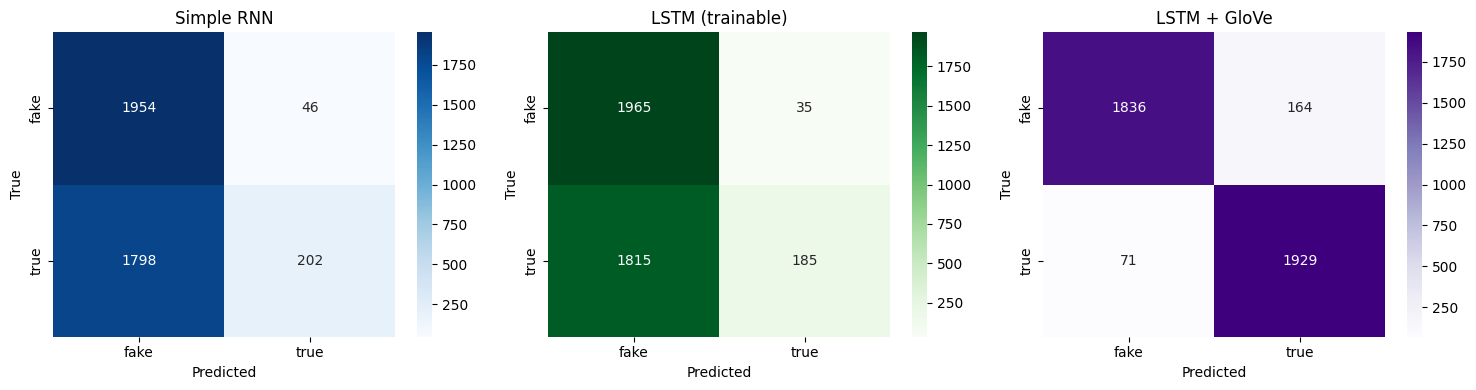


=== Three-Way Comparison ===
           Model  Test acc  Precision  Recall     F1  Train time (min)
      Simple RNN    0.5390     0.8145  0.1010 0.1797              3.49
LSTM (trainable)    0.5375     0.8409  0.0925 0.1667              8.09
    LSTM + GloVe    0.9413     0.9216  0.9645 0.9426              5.50


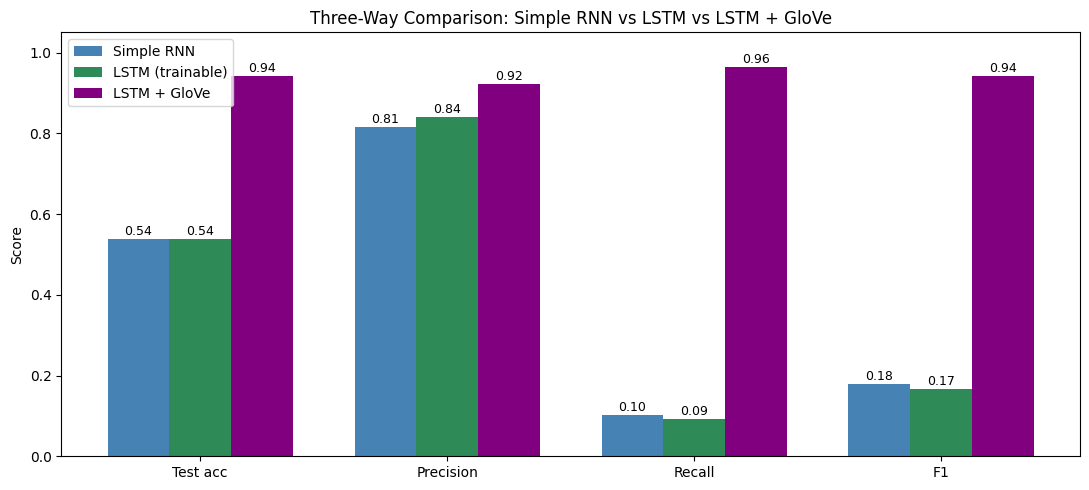

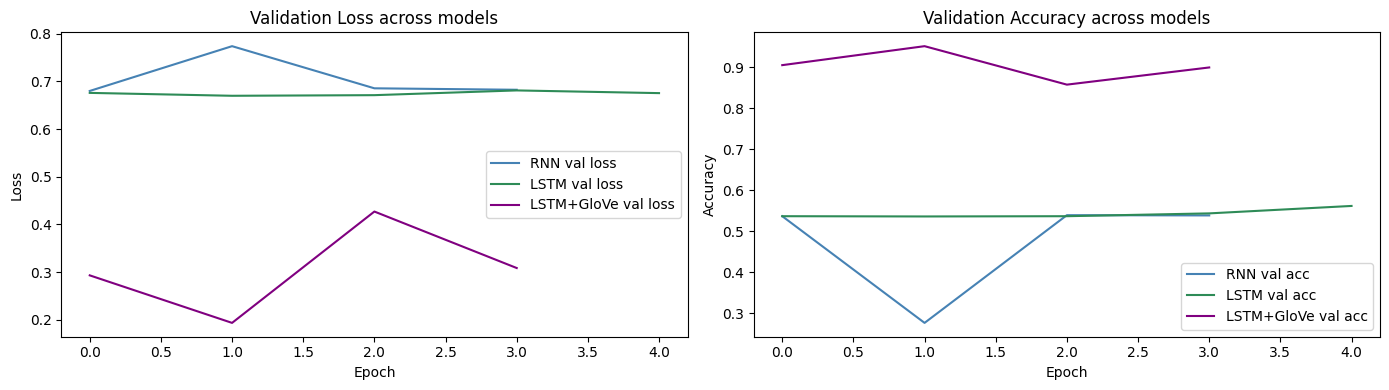

In [16]:
# ============================================================
# NLP BLOCK 11: Evaluate and Compare All Three NLP Models
# ============================================================
# This block produces, for each model:
#   - Predictions on the test set
#   - Classification report (precision, recall, F1)
#   - Confusion matrix
# Then it puts the three side by side in:
#   - A summary table
#   - A bar chart of accuracy/precision/recall/F1
#   - A training curves comparison plot
# Finally, the assignment requires error analysis - showing
# misclassified examples and discussing why they are hard.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)


# ---------- Helper: predict and produce metrics ----------
def evaluate_model(model, X_test, y_test, name):
    """
    Run model.predict, threshold at 0.5, then compute and print
    classification report. Return a dict of headline metrics.
    """
    # predict returns probabilities; threshold at 0.5 for binary class
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred,
                                target_names=["fake", "true"]))

    return {
        "name":       name,
        "y_pred":     y_pred,
        "y_prob":     y_prob,
        "accuracy":   accuracy_score(y_test, y_pred),
        "precision":  precision_score(y_test, y_pred),
        "recall":     recall_score(y_test, y_pred),
        "f1":         f1_score(y_test, y_pred),
    }


# Run evaluation on all three models
rnn_results   = evaluate_model(rnn_model,         X_test, y_test, "Simple RNN")
lstm_results  = evaluate_model(lstm_model,        X_test, y_test, "LSTM (trainable)")
glove_results = evaluate_model(glove_model_keras, X_test, y_test, "LSTM + GloVe")


# ---------- Confusion matrices side by side ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, results, color in zip(
    axes,
    [rnn_results, lstm_results, glove_results],
    ["Blues", "Greens", "Purples"]
):
    cm = confusion_matrix(y_test, results["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap=color,
                xticklabels=["fake", "true"],
                yticklabels=["fake", "true"], ax=ax)
    ax.set_title(results["name"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()


# ---------- Summary table ----------
summary = pd.DataFrame([
    {"Model": "Simple RNN",
     "Test acc":   round(rnn_results["accuracy"], 4),
     "Precision":  round(rnn_results["precision"], 4),
     "Recall":     round(rnn_results["recall"], 4),
     "F1":         round(rnn_results["f1"], 4),
     "Train time (min)": round(rnn_train_time/60, 2)},
    {"Model": "LSTM (trainable)",
     "Test acc":   round(lstm_results["accuracy"], 4),
     "Precision":  round(lstm_results["precision"], 4),
     "Recall":     round(lstm_results["recall"], 4),
     "F1":         round(lstm_results["f1"], 4),
     "Train time (min)": round(lstm_train_time/60, 2)},
    {"Model": "LSTM + GloVe",
     "Test acc":   round(glove_results["accuracy"], 4),
     "Precision":  round(glove_results["precision"], 4),
     "Recall":     round(glove_results["recall"], 4),
     "F1":         round(glove_results["f1"], 4),
     "Train time (min)": round(glove_train_time/60, 2)},
])

print("\n=== Three-Way Comparison ===")
print(summary.to_string(index=False))


# ---------- Bar chart of metrics ----------
metric_cols = ["Test acc", "Precision", "Recall", "F1"]
x = np.arange(len(metric_cols))
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - width, summary.loc[0, metric_cols].astype(float),
        width, label="Simple RNN", color="steelblue")
plt.bar(x,         summary.loc[1, metric_cols].astype(float),
        width, label="LSTM (trainable)", color="seagreen")
plt.bar(x + width, summary.loc[2, metric_cols].astype(float),
        width, label="LSTM + GloVe", color="purple")
plt.xticks(x, metric_cols)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Three-Way Comparison: Simple RNN vs LSTM vs LSTM + GloVe")
plt.legend()
for i, m in enumerate(metric_cols):
    plt.text(i - width, summary.loc[0, m] + 0.01,
             f"{summary.loc[0, m]:.2f}", ha="center", fontsize=9)
    plt.text(i,         summary.loc[1, m] + 0.01,
             f"{summary.loc[1, m]:.2f}", ha="center", fontsize=9)
    plt.text(i + width, summary.loc[2, m] + 0.01,
             f"{summary.loc[2, m]:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


# ---------- Training curves comparison ----------
# Validation loss and accuracy across the three models, on the
# same axes for a direct visual read of which trained best.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(rnn_history.history["val_loss"],
             label="RNN val loss", color="steelblue")
axes[0].plot(lstm_history.history["val_loss"],
             label="LSTM val loss", color="seagreen")
axes[0].plot(glove_history.history["val_loss"],
             label="LSTM+GloVe val loss", color="purple")
axes[0].set_title("Validation Loss across models")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(rnn_history.history["val_accuracy"],
             label="RNN val acc", color="steelblue")
axes[1].plot(lstm_history.history["val_accuracy"],
             label="LSTM val acc", color="seagreen")
axes[1].plot(glove_history.history["val_accuracy"],
             label="LSTM+GloVe val acc", color="purple")
axes[1].set_title("Validation Accuracy across models")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# NLP BLOCK 12: Error Analysis
# ============================================================
# The assignment specifically asks for error analysis:
#   - Show 2-3 incorrect predictions
#   - Discuss possible reasons for errors
#   - Suggest improvements
#
# We use the LSTM model (Model 2) as the primary model for
# error analysis because it usually performs best of the three.
# ============================================================

# Identify which test articles the LSTM got wrong
y_pred_lstm = lstm_results["y_pred"]
y_prob_lstm = lstm_results["y_prob"]
wrong_indices = np.where(y_pred_lstm != y_test)[0]

print(f"LSTM got {len(wrong_indices)} of {len(y_test)} test articles wrong "
      f"({100 * len(wrong_indices) / len(y_test):.2f}%).\n")

# Show 3 sample errors with their original text and confidence
np.random.seed(SEED)
sample_errors = np.random.choice(wrong_indices,
                                 size=min(3, len(wrong_indices)),
                                 replace=False)

label_map = {0: "fake", 1: "true"}
for i, idx in enumerate(sample_errors):
    print(f"--- Error example {i+1} ---")
    print(f"True label:      {label_map[y_test[idx]]}")
    print(f"Predicted label: {label_map[y_pred_lstm[idx]]}")
    print(f"Model confidence: {y_prob_lstm[idx]:.3f}")
    # Show the first 400 chars of the original (un-cleaned) article
    original_idx = np.where(df["clean_text"].values == X_test_text[idx])[0]
    if len(original_idx):
        print("Original snippet:")
        print(df["text"].iloc[original_idx[0]][:400], "...")
    print()

LSTM got 1850 of 4000 test articles wrong (46.25%).

--- Error example 1 ---
True label:      true
Predicted label: fake
Model confidence: 0.457
Original snippet:
WASHINGTON (Reuters) - The U.S. Senate Banking Committee’s top Democrat tussled with Treasury Secretary Steven Mnuchin during a hearing on Thursday over the flow of information from his agency, and later asked if President Donald Trump, a Republican, had ordered him to restrain communications with Democrats. “Are you aware of any White House guidance formal or informal urging administration offici ...

--- Error example 2 ---
True label:      true
Predicted label: fake
Model confidence: 0.457
Original snippet:
CHICAGO (Reuters) - A federal judge in Illinois on Tuesday blocked same-day registration at polling places in the state’s most populous counties, saying a law enacted last year disproportionately favored urban voters over their rural counterparts. The ruling resulted from a federal court lawsuit brought in August by a g

In [19]:
# ============================================================
# NLP BLOCK 13: Real-Time Prediction GUI with Gradio
# ============================================================
# The assignment asks for a simple GUI to enter text and get a
# prediction. Gradio is the easiest choice in Colab because:
#   - It works inside notebooks without external setup.
#   - It produces a public shareable link (useful for the viva
#     so the examiner can interact with the model directly).
#
# Pipeline inside the prediction function:
#   1. Take user input text.
#   2. Apply the same cleaning pipeline used for training
#      (clean_text from NLP Block 5).
#   3. Tokenize using the same tokenizer as training.
#   4. Pad to the same MAX_LEN.
#   5. Predict using the LSTM (trainable embedding) model,
#      which gave the highest test accuracy among the three
#      models we trained.
#   6. Return the label and confidence.
# ============================================================

# Install gradio if not already available
!pip install -q gradio

import gradio as gr
import numpy as np


def predict_news(text):
    """
    Take raw news text, run it through the same preprocessing
    pipeline used during training, then predict with the LSTM
    model and return a human-readable result string.
    """
    # Reject empty or whitespace-only input
    if not text or not text.strip():
        return "Please enter some news text."

    # Step 1: clean the text using the same pipeline as training
    cleaned = clean_text(text)
    if not cleaned:
        return "After cleaning, the text is empty. Try a longer article."

    # Step 2: tokenize and pad (same tokenizer and MAX_LEN as training)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN,
                           padding="post", truncating="post")

    # Step 3: predict. The model returns a single probability.
    prob = float(lstm_model.predict(padded, verbose=0).ravel()[0])

    # Step 4: convert probability to label and confidence.
    # Probability is the model's belief that label == 1 (true).
    # If prob >= 0.5 we predict TRUE; the displayed confidence
    # is the higher of (prob, 1 - prob).
    if prob >= 0.5:
        label = "TRUE NEWS"
        confidence = prob
    else:
        label = "FAKE NEWS"
        confidence = 1.0 - prob

    return (
        f"Prediction: {label}\n"
        f"Confidence: {confidence*100:.2f}%\n"
        f"Raw probability of TRUE: {prob:.4f}"
    )


# Build the Gradio interface
with gr.Blocks(title="Fake News Detector") as demo:
    gr.Markdown("# Fake News Detector")
    gr.Markdown(
        "Enter a news article (or paste a snippet) below. The LSTM "
        "model predicts whether the news is TRUE or FAKE."
    )

    with gr.Row():
        with gr.Column():
            input_text = gr.Textbox(
                lines=8,
                placeholder="Paste a news article here...",
                label="News text"
            )
            predict_button = gr.Button("Predict")
        with gr.Column():
            output_text = gr.Textbox(label="Result", lines=5)

    # Bind the button click to the prediction function
    predict_button.click(
        fn=predict_news,
        inputs=input_text,
        outputs=output_text
    )

    # A couple of example articles for quick testing during viva
    gr.Examples(
        examples=[
            "WASHINGTON (Reuters) - The U.S. Senate on Thursday "
            "passed a bipartisan bill aimed at strengthening "
            "cybersecurity standards across federal agencies, "
            "with a vote of 88 to 11. The bill now heads to the "
            "House for further consideration.",

            "BREAKING: Scientists have discovered that drinking "
            "lemon water cures all forms of cancer in just 3 days, "
            "according to a secret study Big Pharma does not want "
            "you to know about! Share before they delete this!",
        ],
        inputs=input_text,
    )

# Launch with share=True so a public URL is created.
# The public link is valid for about 7 days.
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://92b46aa630467fc09a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
